In [1]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["JAX_PLATFORM_NAME"] = "cpu"

import jax_fli as jfli
import datasets

BASE = '/home/wassim/Projects/NBody/jax-fli-result/results/02-density_width_shell_selection/catalogs'

METHODS = {
    "multi_shell":              f"{BASE}/multi_shell",
    "DRIFT":                    f"{BASE}/multi_shell_drift",
    "DRIFT_EQ":                 f"{BASE}/multi_shell_drift_equal_vol",
}
NS_VALUES = [10, 20, 30]

def parquet_path(directory, ns):
    return f"{directory}/nbody_M2048x2048x2048_B6000x6000x6000_Oc0.2589_S80.8159_s0_Ns{ns}_Nst30_nside1024.parquet"

In [2]:
from tqdm import tqdm

# spectra[(method, ns)] = list of per-shell AngularCl objects
spectra = {}

for method, directory in METHODS.items():
    for ns in NS_VALUES:
        path = parquet_path(directory, ns)
        ds = datasets.load_dataset("parquet", data_files=[path], split="train").with_format("numpy")
        item = ds[0]
        catalog = jfli.io.Catalog.from_dataset(item)
        field = catalog.field[0]
        overdensity_lc = (field / field.mean(axis=1, keepdims=True)) - 1.
        angular_cl = overdensity_lc.angular_cl(method="healpy")
        spectra[(method, ns)] = angular_cl
        print(f"  {method}, Ns={ns}: {field.shape[0]} shells, done")

print("Done.")

Generating train split: 0 examples [00:00, ? examples/s]

  multi_shell, Ns=10: 10 shells, done


Generating train split: 0 examples [00:00, ? examples/s]

  multi_shell, Ns=20: 20 shells, done


Generating train split: 0 examples [00:00, ? examples/s]

...

  DRIFT_EQ, Ns=10: 10 shells, done


Generating train split: 0 examples [00:00, ? examples/s]

  DRIFT_EQ, Ns=20: 20 shells, done


Generating train split: 0 examples [00:00, ? examples/s]

  DRIFT_EQ, Ns=30: 30 shells, done
Done.


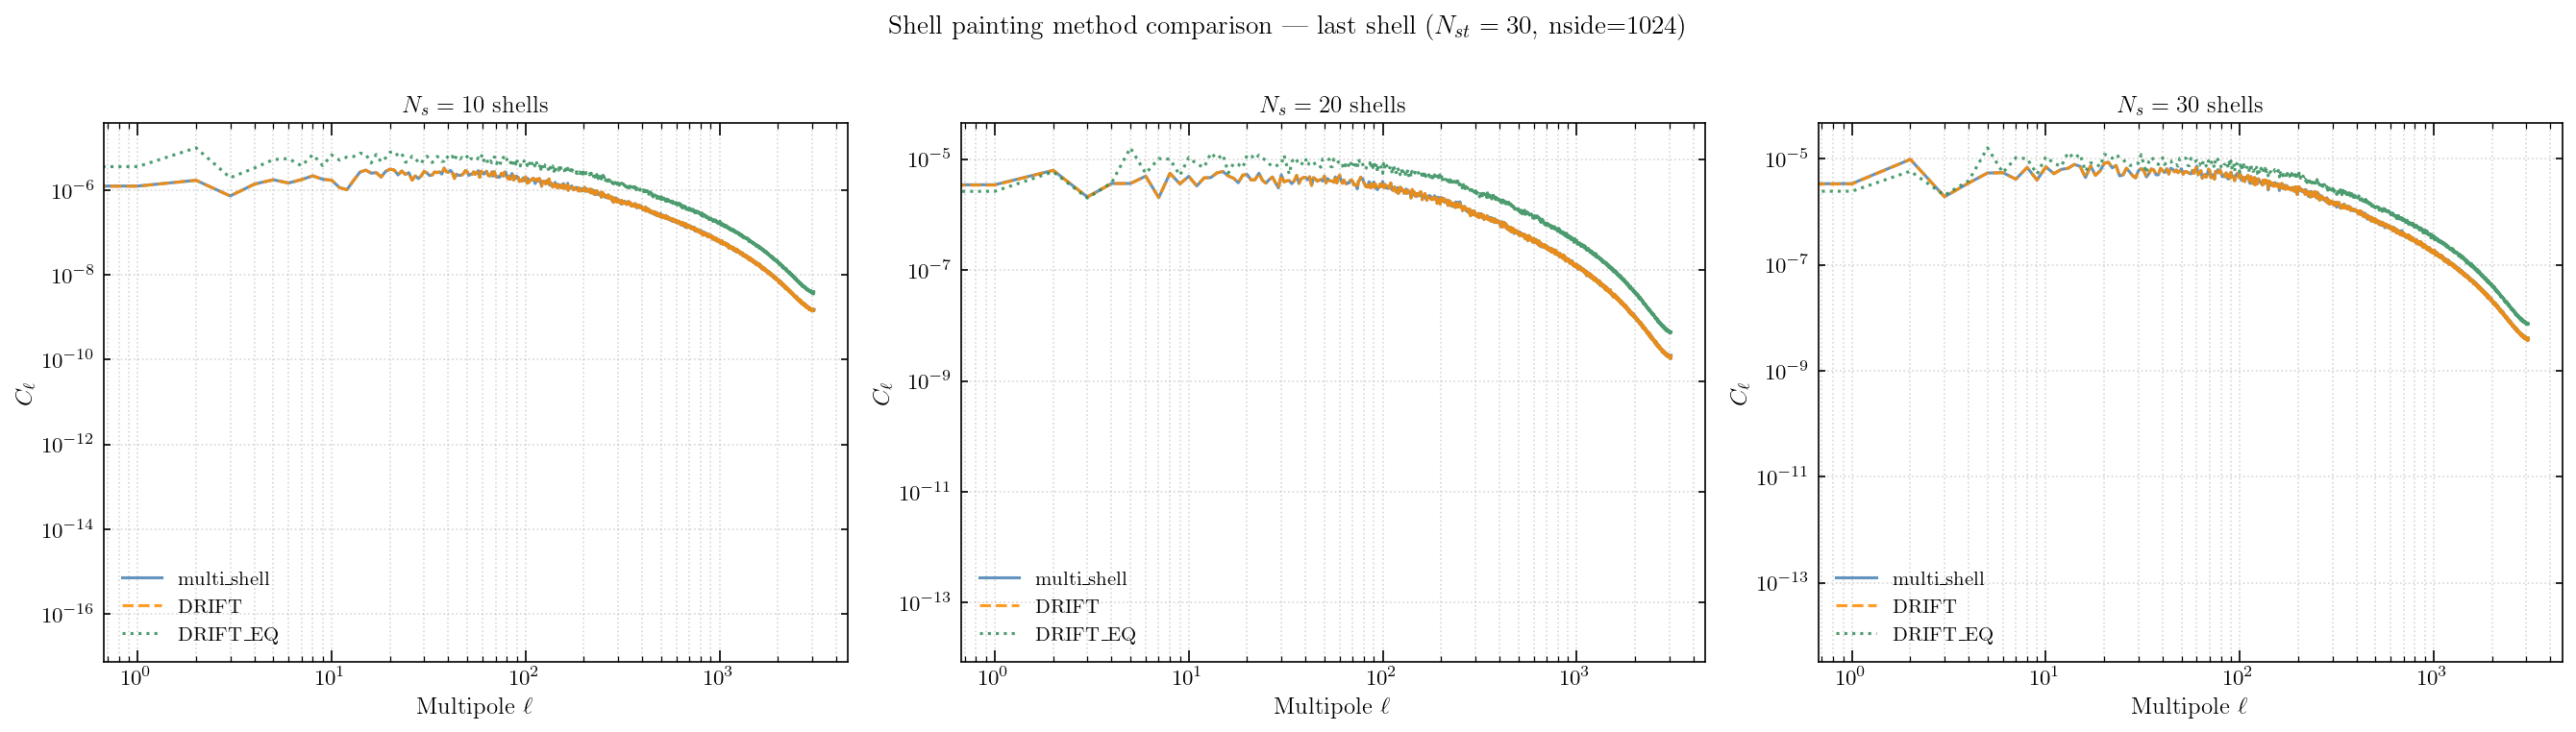

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from utils import set_jcap_style

set_jcap_style()

SHELL_IDX = -1   # compare last shell across all configurations
METHOD_STYLES = {
    "multi_shell": dict(color="steelblue",  linestyle="-",  label=r"multi\_shell"),
    "DRIFT":       dict(color="darkorange", linestyle="--", label="DRIFT"),
    "DRIFT_EQ":    dict(color="seagreen",   linestyle=":",  label=r"DRIFT\_EQ"),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for col, ns in enumerate(NS_VALUES):
    ax = axes[col]
    for method in METHODS:
        cl_shell = spectra[(method, ns)][SHELL_IDX]
        cl_shell.plot(ax=ax, logx=True, logy=True,
                      alpha=0.85, **METHOD_STYLES[method])
    ax.set_title(f"$N_s = {ns}$ shells")
    ax.set_xlabel(r"Multipole $\ell$")
    ax.set_ylabel(r"$C_\ell$")
    ax.legend()

plt.suptitle(r"Shell painting method comparison — last shell ($N_{st}=30$, nside=1024)", y=1.01)
plt.tight_layout()
plt.show()